In [ ]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv("BankingFraudDetection.csv")

print("Dataset Loaded Successfully")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

Dataset Loaded Successfully
  transaction_time  transaction_amount  avg_transaction_30d  \
0            00:19           257350.80                 8726   
1            07:44             6497.26                 8071   
2            00:20           571517.63                17900   
3            07:21            22261.74                19912   
4            16:14            24699.35                24748   

   transaction_frequency_10min current_location previous_location  \
0                            5            Patna              Pune   
1                            1       Chandigarh        Chandigarh   
2                            7           Karwar         Bengaluru   
3                            1         Belagavi          Belagavi   
4                            1         Bagalkot          Bagalkot   

   account_balance transaction_type  account_age_days  failed_login_attempts  \
0        461800.68       Withdrawal              1076                      3   
1        111991.44

In [ ]:
# ============================================================
# PREPROCESSING CLASS FOR REUSABILITY
# ============================================================

class FraudDetectionPreprocessor:

    def __init__(self):
        self.encoders = {}
        self.scaler = StandardScaler()
        self.categorical_cols = [
            "transaction_time",
            "current_location",
            "previous_location",
            "transaction_type"
        ]
        self.fraud_label_encoder = None
        self.is_fitted = False
    
    def fit(self, df, target_col="fraud_label"):
        """Fit encoders and scaler on training data"""
        df_copy = df.copy()
        
        # Fit label encoder for TARGET variable
        self.fraud_label_encoder = LabelEncoder()
        df_copy[target_col] = self.fraud_label_encoder.fit_transform(df_copy[target_col])
        
        # Fit label encoders for CATEGORICAL features
        for col in self.categorical_cols:
            le = LabelEncoder()
            df_copy[col] = le.fit_transform(df_copy[col])
            self.encoders[col] = le
        
        # Get features (exclude targets)
        X = df_copy.drop([target_col, "risk_score"], axis=1)
        
        # Fit scaler
        self.scaler.fit(X)
        self.is_fitted = True
        
        return df_copy
    
    def transform(self, df, target_col="fraud_label"):
        """Transform data using fitted encoders and scaler"""
        if not self.is_fitted:
            raise ValueError("Preprocessor must be fitted before transform")
        
        df_copy = df.copy()
        
        # Encode target variable if present
        if target_col in df_copy.columns:
            df_copy[target_col] = self.fraud_label_encoder.transform(df_copy[target_col])
        
        # Encode categorical columns
        for col in self.categorical_cols:
            if col in df_copy.columns:
                df_copy[col] = self.encoders[col].transform(df_copy[col])
        
        return df_copy
    
    def scale_features(self, X):
        """Scale numerical features"""
        return self.scaler.transform(X)
    
    def get_feature_names(self, df):
        """Get feature names excluding targets"""
        return df.drop(["fraud_label", "risk_score"], axis=1, errors='ignore').columns.tolist()

# Initialize preprocessor
preprocessor = FraudDetectionPreprocessor()
print("Preprocessor Class Initialized")

Preprocessor Class Initialized


In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFraud Distribution:")
print(df["fraud_label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_time             2000 non-null   str    
 1   transaction_amount           2000 non-null   float64
 2   avg_transaction_30d          2000 non-null   int64  
 3   transaction_frequency_10min  2000 non-null   int64  
 4   current_location             2000 non-null   str    
 5   previous_location            2000 non-null   str    
 6   account_balance              2000 non-null   float64
 7   transaction_type             2000 non-null   str    
 8   account_age_days             2000 non-null   int64  
 9   failed_login_attempts        2000 non-null   int64  
 10  login_hour                   2000 non-null   int64  
 11  transactions_today           2000 non-null   int64  
 12  risk_score                   2000 non-null   int64  
 13  fraud_label                  

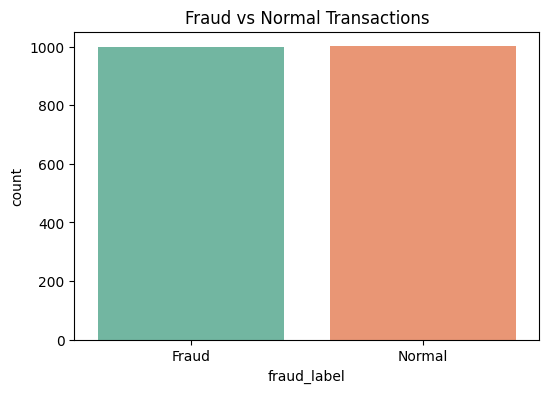

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["fraud_label"], palette="Set2")

plt.title("Fraud vs Normal Transactions")
plt.show()

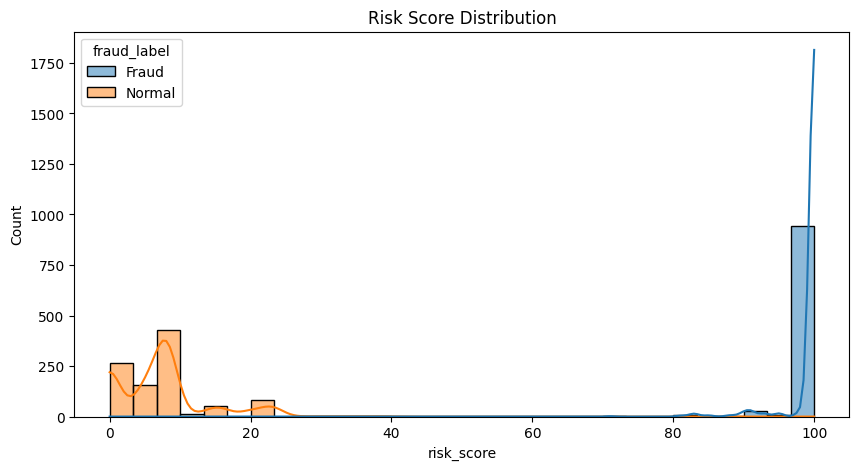

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="risk_score",
    hue="fraud_label",
    kde=True,
    bins=30
)

plt.title("Risk Score Distribution")
plt.show()

In [ ]:
# Store original risk_score before preprocessing
df_processed = df.copy()
risk_score_original = df_processed["risk_score"].copy()

# Fit and transform
df_processed = preprocessor.fit(df_processed)

print("Encoding Completed")
print(f"Categorical columns encoded: {preprocessor.categorical_cols}")

Encoding Completed
Categorical columns encoded: ['transaction_time', 'current_location', 'previous_location', 'transaction_type']


In [ ]:
print("Unique categories in training data:\n")

print(f"fraud_label: {list(preprocessor.fraud_label_encoder.classes_)}\n")

for col in preprocessor.categorical_cols:
    classes = list(preprocessor.encoders[col].classes_)
    print(f"{col}: {classes}\n")

Unique categories in training data:

fraud_label: ['Fraud', 'Normal']

transaction_time: ['00:00', '00:01', '00:02', '00:03', '00:04', '00:05', '00:06', '00:07', '00:08', '00:09', '00:10', '00:11', '00:12', '00:13', '00:14', '00:15', '00:16', '00:17', '00:18', '00:19', '00:20', '00:21', '00:22', '00:23', '00:24', '00:25', '00:26', '00:27', '00:28', '00:29', '00:30', '00:31', '00:32', '00:33', '00:34', '00:35', '00:36', '00:37', '00:38', '00:39', '00:40', '00:41', '00:42', '00:43', '00:44', '00:45', '00:46', '00:47', '00:48', '00:49', '00:50', '00:51', '00:52', '00:53', '00:54', '00:55', '00:56', '00:57', '00:58', '00:59', '01:00', '01:01', '01:02', '01:03', '01:04', '01:05', '01:06', '01:07', '01:08', '01:09', '01:10', '01:11', '01:12', '01:13', '01:14', '01:15', '01:16', '01:17', '01:18', '01:19', '01:20', '01:21', '01:22', '01:23', '01:24', '01:25', '01:26', '01:27', '01:28', '01:29', '01:30', '01:31', '01:32', '01:33', '01:34', '01:35', '01:36', '01:37', '01:38', '01:39', '01:40', '

In [ ]:
# Get features (exclude both targets: fraud_label and risk_score)
X = df_processed.drop(["fraud_label", "risk_score"], axis=1)

# Regression Target: risk_score prediction
y_regression = risk_score_original

# Classification Target: fraud detection
y_classification = df_processed["fraud_label"]

print("Feature Selection Complete")
print(f"Features Shape: {X.shape}")
print(f"Regression Target (risk_score) Shape: {y_regression.shape}")
print(f"Classification Target (fraud_label) Shape: {y_classification.shape}")
print(f"\nFeatures: {list(X.columns)}")

Feature Selection Complete
Features Shape: (2000, 12)
Regression Target (risk_score) Shape: (2000,)
Classification Target (fraud_label) Shape: (2000,)

Features: ['transaction_time', 'transaction_amount', 'avg_transaction_30d', 'transaction_frequency_10min', 'current_location', 'previous_location', 'account_balance', 'transaction_type', 'account_age_days', 'failed_login_attempts', 'login_hour', 'transactions_today']


In [ ]:
# Split for classification task (fraud detection)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

# Split for regression task (risk_score prediction)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Complete")
print(f"\nClassification Task:")
print(f"  Training Shape: {X_train_clf.shape}")
print(f"  Testing Shape: {X_test_clf.shape}")
print(f"\nRegression Task:")
print(f"  Training Shape: {X_train_reg.shape}")
print(f"  Testing Shape: {X_test_reg.shape}")

Train-Test Split Complete

Classification Task:
  Training Shape: (1600, 12)
  Testing Shape: (400, 12)

Regression Task:
  Training Shape: (1600, 12)
  Testing Shape: (400, 12)


In [ ]:
# Scale features for classification
X_train_clf_scaled = preprocessor.scale_features(X_train_clf)
X_test_clf_scaled = preprocessor.scale_features(X_test_clf)

# Scale features for regression
X_train_reg_scaled = preprocessor.scale_features(X_train_reg)
X_test_reg_scaled = preprocessor.scale_features(X_test_reg)

print("Feature Scaling Completed for Both Tasks")
print(f"\nClassification - Scaled Training Shape: {X_train_clf_scaled.shape}")
print(f"Classification - Scaled Testing Shape: {X_test_clf_scaled.shape}")
print(f"\nRegression - Scaled Training Shape: {X_train_reg_scaled.shape}")
print(f"Regression - Scaled Testing Shape: {X_test_reg_scaled.shape}")

Feature Scaling Completed for Both Tasks

Classification - Scaled Training Shape: (1600, 12)
Classification - Scaled Testing Shape: (400, 12)

Regression - Scaled Training Shape: (1600, 12)
Regression - Scaled Testing Shape: (400, 12)


In [ ]:
rf_clf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_clf_model.fit(X_train_clf_scaled, y_train_clf)

rf_clf_pred = rf_clf_model.predict(X_test_clf_scaled)
rf_clf_proba = rf_clf_model.predict_proba(X_test_clf_scaled)[:,1]

rf_clf_acc = accuracy_score(y_test_clf, rf_clf_pred)
rf_clf_auc = roc_auc_score(y_test_clf, rf_clf_proba)

print("Random Forest Classification Accuracy:", rf_clf_acc)
print("Random Forest Classification AUC:", rf_clf_auc)
print("\nClassification Report:\n")
print(classification_report(y_test_clf, rf_clf_pred))

Random Forest Classification Accuracy: 1.0
Random Forest Classification AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
rf_reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_reg_model.fit(X_train_reg_scaled, y_train_reg)

rf_reg_pred = rf_reg_model.predict(X_test_reg_scaled)

rf_reg_mse = mean_squared_error(y_test_reg, rf_reg_pred)
rf_reg_rmse = np.sqrt(rf_reg_mse)
rf_reg_mae = mean_absolute_error(y_test_reg, rf_reg_pred)
rf_reg_r2 = r2_score(y_test_reg, rf_reg_pred)

print("Random Forest Regression (Risk Score Prediction)")
print(f"  MSE: {rf_reg_mse:.4f}")
print(f"  RMSE: {rf_reg_rmse:.4f}")
print(f"  MAE: {rf_reg_mae:.4f}")
print(f"  R² Score: {rf_reg_r2:.4f}")


Random Forest Regression (Risk Score Prediction)
  MSE: 10.1012
  RMSE: 3.1782
  MAE: 1.5088
  R² Score: 0.9953


In [ ]:
xgb_clf_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf_model.fit(X_train_clf_scaled, y_train_clf)

xgb_clf_pred = xgb_clf_model.predict(X_test_clf_scaled)
xgb_clf_proba = xgb_clf_model.predict_proba(X_test_clf_scaled)[:,1]

xgb_clf_acc = accuracy_score(y_test_clf, xgb_clf_pred)
xgb_clf_auc = roc_auc_score(y_test_clf, xgb_clf_proba)

print("XGBoost Classification Accuracy:", xgb_clf_acc)
print("XGBoost Classification AUC:", xgb_clf_auc)
print("\nClassification Report:\n")
print(classification_report(y_test_clf, xgb_clf_pred))

XGBoost Classification Accuracy: 1.0
XGBoost Classification AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
xgb_reg_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg_model.fit(X_train_reg_scaled, y_train_reg)

xgb_reg_pred = xgb_reg_model.predict(X_test_reg_scaled)

xgb_reg_mse = mean_squared_error(y_test_reg, xgb_reg_pred)
xgb_reg_rmse = np.sqrt(xgb_reg_mse)
xgb_reg_mae = mean_absolute_error(y_test_reg, xgb_reg_pred)
xgb_reg_r2 = r2_score(y_test_reg, xgb_reg_pred)

print("XGBoost Regression (Risk Score Prediction)")
print(f"  MSE: {xgb_reg_mse:.4f}")
print(f"  RMSE: {xgb_reg_rmse:.4f}")
print(f"  MAE: {xgb_reg_mae:.4f}")
print(f"  R² Score: {xgb_reg_r2:.4f}")


XGBoost Regression (Risk Score Prediction)
  MSE: 8.9665
  RMSE: 2.9944
  MAE: 1.4340
  R² Score: 0.9959


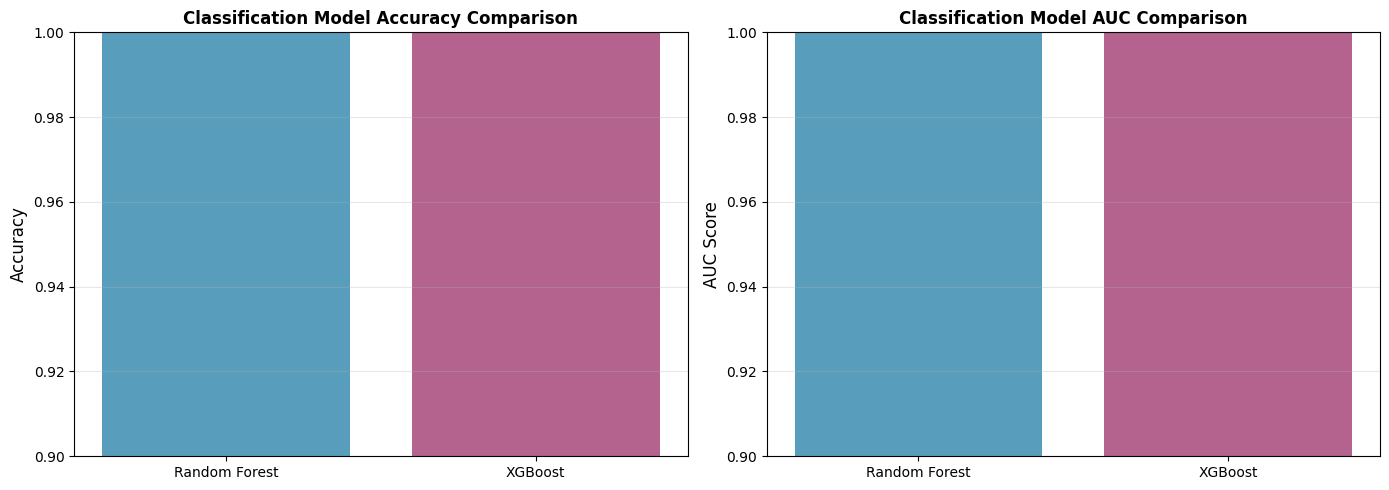

Classification Models Summary:
Random Forest - Accuracy: 1.0000, AUC: 1.0000
XGBoost - Accuracy: 1.0000, AUC: 1.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification Accuracy Comparison
models_clf = ["Random Forest", "XGBoost"]
accuracies = [rf_clf_acc, xgb_clf_acc]
aucs = [rf_clf_auc, xgb_clf_auc]

axes[0].bar(models_clf, accuracies, color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[0].set_ylim(0.9, 1.0)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Classification Model Accuracy Comparison", fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# AUC Comparison
axes[1].bar(models_clf, aucs, color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[1].set_ylim(0.9, 1.0)
axes[1].set_ylabel("AUC Score", fontsize=12)
axes[1].set_title("Classification Model AUC Comparison", fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Classification Models Summary:")
print(f"Random Forest - Accuracy: {rf_clf_acc:.4f}, AUC: {rf_clf_auc:.4f}")
print(f"XGBoost - Accuracy: {xgb_clf_acc:.4f}, AUC: {xgb_clf_auc:.4f}")

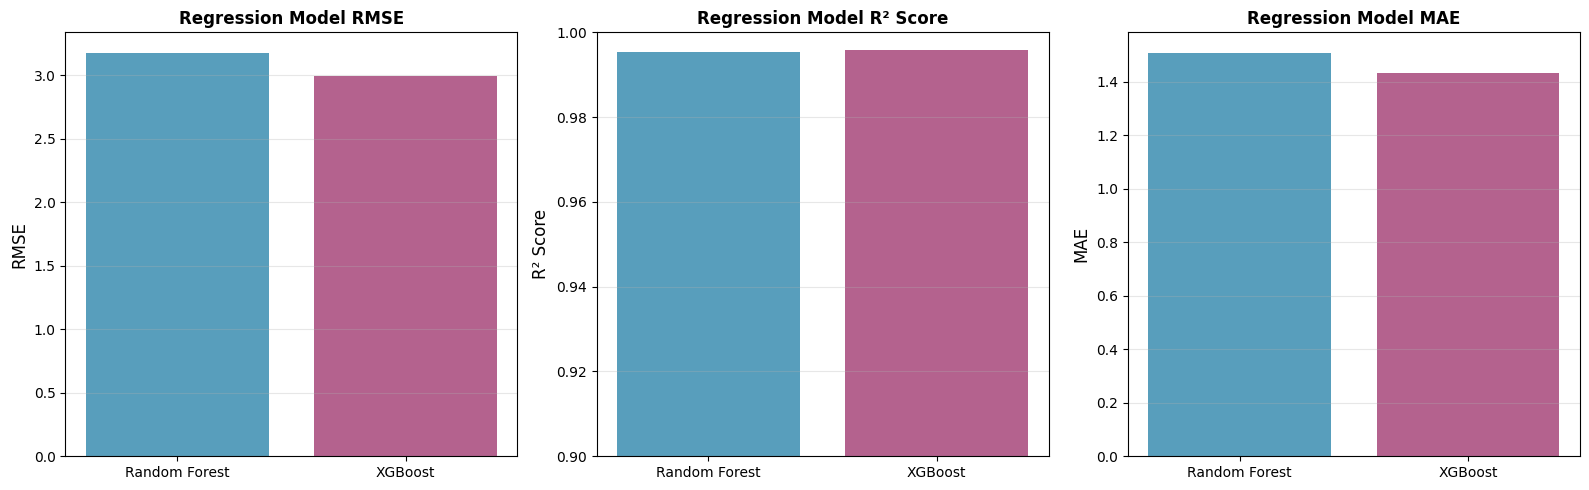

Regression Models Summary:
Random Forest - RMSE: 3.1782, R²: 0.9953, MAE: 1.5088
XGBoost - RMSE: 2.9944, R²: 0.9959, MAE: 1.4340


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE Comparison
models_reg = ["Random Forest", "XGBoost"]
rmses = [rf_reg_rmse, xgb_reg_rmse]
r2_scores = [rf_reg_r2, xgb_reg_r2]
maes = [rf_reg_mae, xgb_reg_mae]

axes[0].bar(models_reg, rmses, color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[0].set_ylabel("RMSE", fontsize=12)
axes[0].set_title("Regression Model RMSE", fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1].bar(models_reg, r2_scores, color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[1].set_ylim(0.9, 1.0)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_title("Regression Model R² Score", fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[2].bar(models_reg, maes, color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[2].set_ylabel("MAE", fontsize=12)
axes[2].set_title("Regression Model MAE", fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Regression Models Summary:")
print(f"Random Forest - RMSE: {rf_reg_rmse:.4f}, R²: {rf_reg_r2:.4f}, MAE: {rf_reg_mae:.4f}")
print(f"XGBoost - RMSE: {xgb_reg_rmse:.4f}, R²: {xgb_reg_r2:.4f}, MAE: {xgb_reg_mae:.4f}")


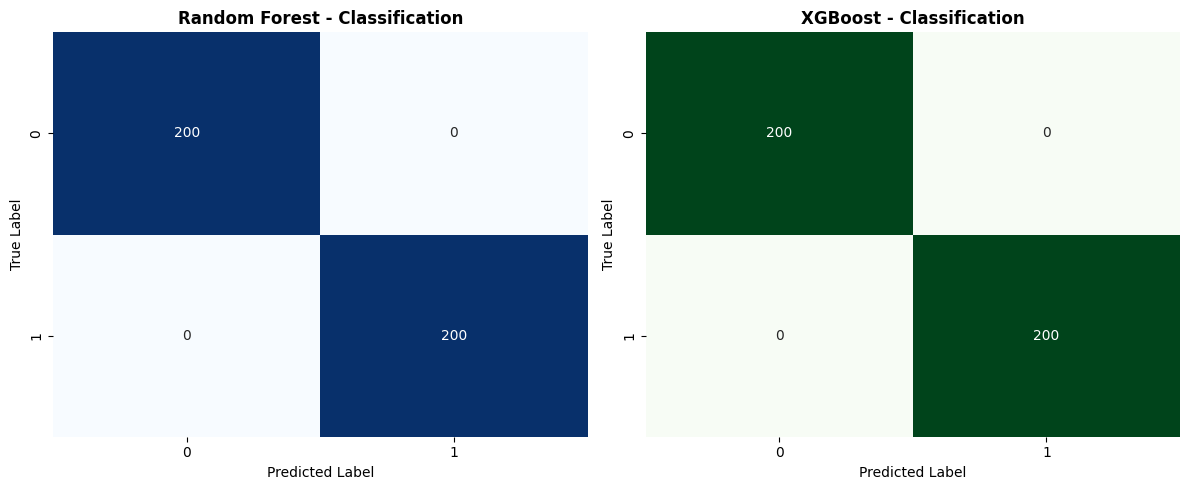

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test_clf, rf_clf_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Random Forest - Classification", fontsize=12, fontweight='bold')
ax[0].set_ylabel("True Label")
ax[0].set_xlabel("Predicted Label")

sns.heatmap(
    confusion_matrix(y_test_clf, xgb_clf_pred),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[1],
    cbar=False
)
ax[1].set_title("XGBoost - Classification", fontsize=12, fontweight='bold')
ax[1].set_ylabel("True Label")
ax[1].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

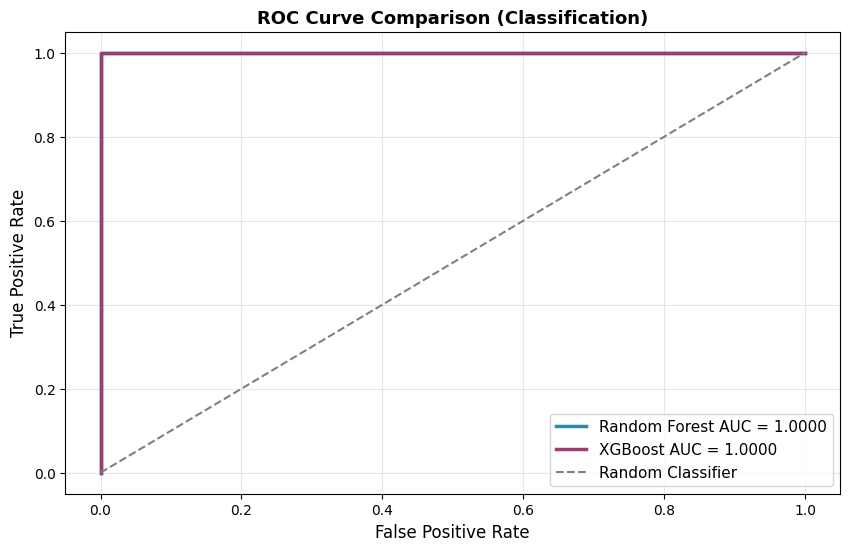

In [ ]:
rf_clf_fpr, rf_clf_tpr, _ = roc_curve(y_test_clf, rf_clf_proba)
xgb_clf_fpr, xgb_clf_tpr, _ = roc_curve(y_test_clf, xgb_clf_proba)

plt.figure(figsize=(10, 6))

plt.plot(
    rf_clf_fpr,
    rf_clf_tpr,
    label=f"Random Forest AUC = {rf_clf_auc:.4f}",
    linewidth=2.5,
    color='#2E86AB'
)

plt.plot(
    xgb_clf_fpr,
    xgb_clf_tpr,
    label=f"XGBoost AUC = {xgb_clf_auc:.4f}",
    linewidth=2.5,
    color='#A23B72'
)

plt.plot([0, 1], [0, 1], linestyle="--", color='gray', linewidth=1.5, label='Random Classifier')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison (Classification)", fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.show()

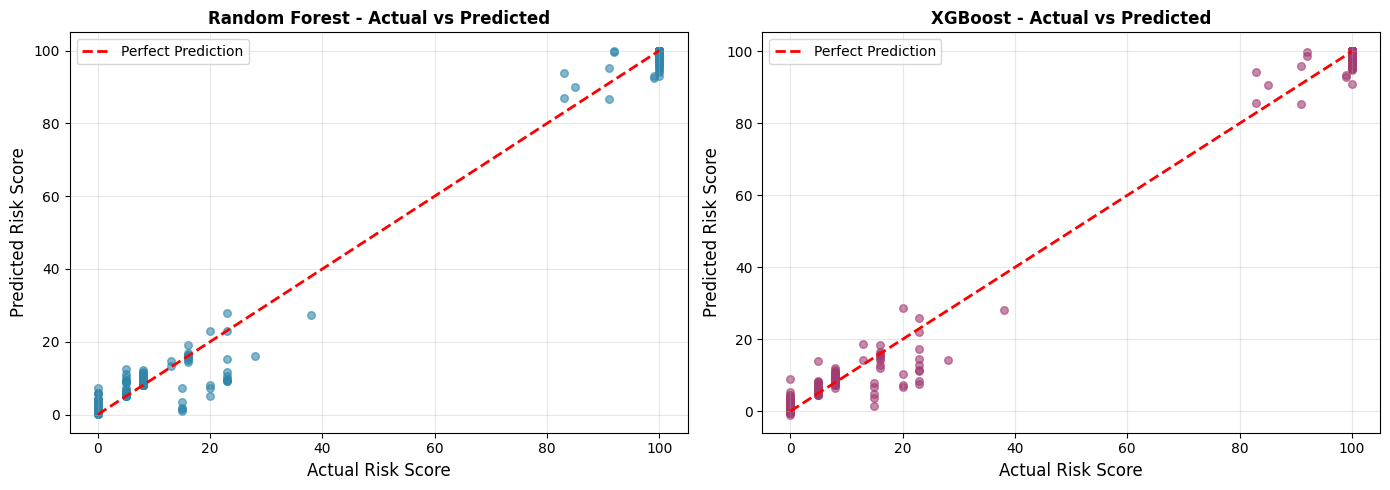

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Regression: Actual vs Predicted
axes[0].scatter(y_test_reg, rf_reg_pred, alpha=0.6, color='#2E86AB', s=30)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], 
             [y_test_reg.min(), y_test_reg.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel("Actual Risk Score", fontsize=12)
axes[0].set_ylabel("Predicted Risk Score", fontsize=12)
axes[0].set_title("Random Forest - Actual vs Predicted", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# XGBoost Regression: Actual vs Predicted
axes[1].scatter(y_test_reg, xgb_reg_pred, alpha=0.6, color='#A23B72', s=30)
axes[1].plot([y_test_reg.min(), y_test_reg.max()], 
             [y_test_reg.min(), y_test_reg.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel("Actual Risk Score", fontsize=12)
axes[1].set_ylabel("Predicted Risk Score", fontsize=12)
axes[1].set_title("XGBoost - Actual vs Predicted", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


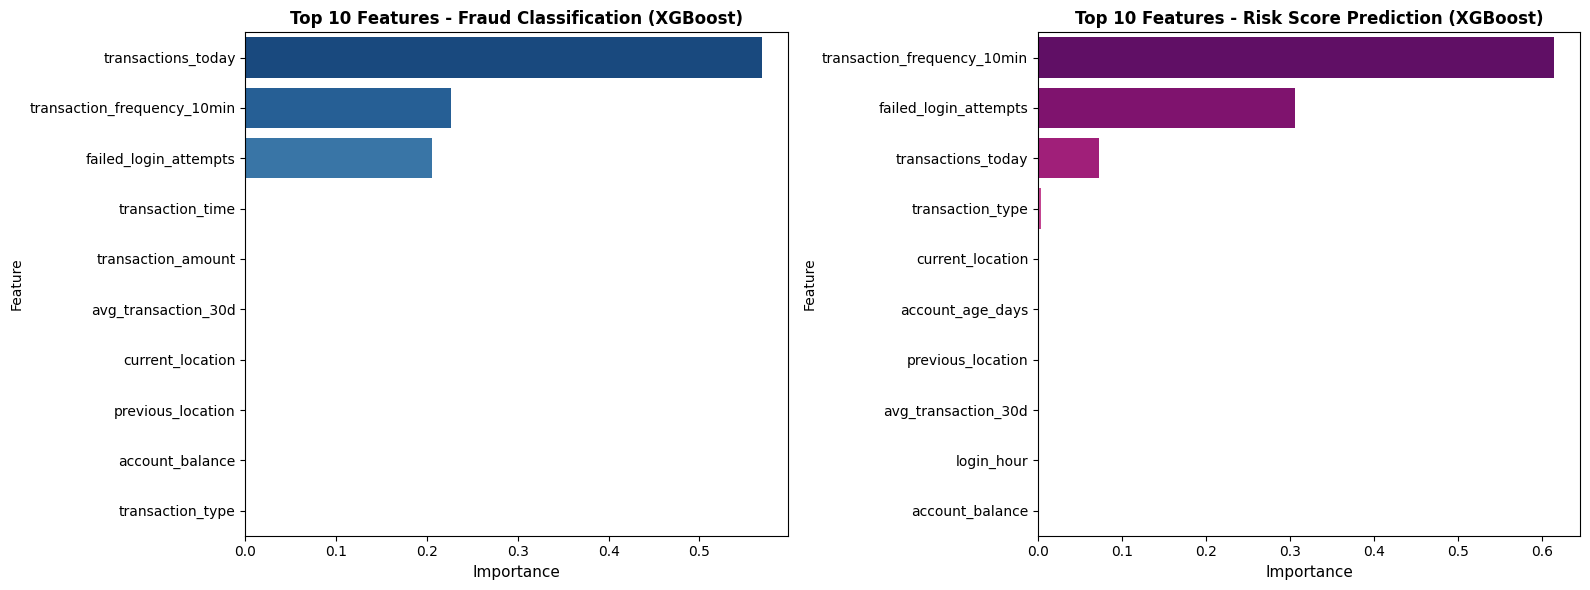

Top Features - Classification Task:
                        Feature  Importance
11           transactions_today    0.568604
3   transaction_frequency_10min    0.226070
9         failed_login_attempts    0.205326
0              transaction_time    0.000000
1            transaction_amount    0.000000
2           avg_transaction_30d    0.000000
4              current_location    0.000000
5             previous_location    0.000000
6               account_balance    0.000000
7              transaction_type    0.000000

Top Features - Regression Task:
                        Feature  Importance
3   transaction_frequency_10min    0.614437
9         failed_login_attempts    0.305653
11           transactions_today    0.072825
7              transaction_type    0.003873
4              current_location    0.000717
8              account_age_days    0.000648
5             previous_location    0.000519
2           avg_transaction_30d    0.000332
10                   login_hour    0.000329
6      

In [ ]:
feature_names = list(X.columns)

# Classification Feature Importance
clf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_clf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Regression Feature Importance
reg_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_reg_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification Feature Importance
sns.barplot(
    data=clf_importance.head(10),
    x="Importance",
    y="Feature",
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Top 10 Features - Fraud Classification (XGBoost)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Importance", fontsize=11)

# Regression Feature Importance
sns.barplot(
    data=reg_importance.head(10),
    x="Importance",
    y="Feature",
    palette="RdPu_r",
    ax=axes[1]
)
axes[1].set_title("Top 10 Features - Risk Score Prediction (XGBoost)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Importance", fontsize=11)

plt.tight_layout()
plt.show()

print("Top Features - Classification Task:")
print(clf_importance.head(10))
print("\nTop Features - Regression Task:")
print(reg_importance.head(10))

In [ ]:
# Select best models based on performance
best_clf_model = xgb_clf_model if xgb_clf_auc > rf_clf_auc else rf_clf_model
best_clf_name = "XGBoost" if xgb_clf_auc > rf_clf_auc else "RandomForest"

best_reg_model = xgb_reg_model if xgb_reg_r2 > rf_reg_r2 else rf_reg_model
best_reg_name = "XGBoost" if xgb_reg_r2 > rf_reg_r2 else "RandomForest"

# Create model metadata
model_metadata = {
    "training_date": datetime.now().isoformat(),
    "classification_task": {
        "model_type": best_clf_name,
        "accuracy": float(max(rf_clf_acc, xgb_clf_acc)),
        "auc_score": float(max(rf_clf_auc, xgb_clf_auc)),
        "rf_accuracy": float(rf_clf_acc),
        "rf_auc": float(rf_clf_auc),
        "xgb_accuracy": float(xgb_clf_acc),
        "xgb_auc": float(xgb_clf_auc),
        "features": feature_names
    },
    "regression_task": {
        "model_type": best_reg_name,
        "rmse": float(min(rf_reg_rmse, xgb_reg_rmse)),
        "r2_score": float(max(rf_reg_r2, xgb_reg_r2)),
        "mae": float(min(rf_reg_mae, xgb_reg_mae)),
        "rf_rmse": float(rf_reg_rmse),
        "rf_r2": float(rf_reg_r2),
        "rf_mae": float(rf_reg_mae),
        "xgb_rmse": float(xgb_reg_rmse),
        "xgb_r2": float(xgb_reg_r2),
        "xgb_mae": float(xgb_reg_mae),
        "features": feature_names
    },
    "preprocessing": {
        "categorical_columns": preprocessor.categorical_cols,
        "scaler_type": "StandardScaler",
        "train_test_split": 0.2
    }
}

# Save models
joblib.dump(best_clf_model, "BestFraudClassificationModel.pkl")
joblib.dump(best_reg_model, "BestRiskScorePredictionModel.pkl")
joblib.dump(preprocessor, "FraudDetectionPreprocessor.pkl")

# Save metadata
with open("model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print("✓ Classification Model Saved: BestFraudClassificationModel.pkl")
print(f"  Type: {best_clf_name} | Accuracy: {model_metadata['classification_task']['accuracy']:.4f} | AUC: {model_metadata['classification_task']['auc_score']:.4f}")

print("\n✓ Regression Model Saved: BestRiskScorePredictionModel.pkl")
print(f"  Type: {best_reg_name} | R² Score: {model_metadata['regression_task']['r2_score']:.4f} | RMSE: {model_metadata['regression_task']['rmse']:.4f}")

print("\n✓ Preprocessor Saved: FraudDetectionPreprocessor.pkl")
print("✓ Metadata Saved: model_metadata.json")

print("\n" + "="*60)
print("MODEL REGISTRY CREATED SUCCESSFULLY")
print("="*60)
print(json.dumps(model_metadata, indent=2))

✓ Classification Model Saved: BestFraudClassificationModel.pkl
  Type: RandomForest | Accuracy: 1.0000 | AUC: 1.0000

✓ Regression Model Saved: BestRiskScorePredictionModel.pkl
  Type: XGBoost | R² Score: 0.9959 | RMSE: 2.9944

✓ Preprocessor Saved: FraudDetectionPreprocessor.pkl
✓ Metadata Saved: model_metadata.json

MODEL REGISTRY CREATED SUCCESSFULLY
{
  "training_date": "2026-05-26T00:32:22.086587",
  "classification_task": {
    "model_type": "RandomForest",
    "accuracy": 1.0,
    "auc_score": 1.0,
    "rf_accuracy": 1.0,
    "rf_auc": 1.0,
    "xgb_accuracy": 1.0,
    "xgb_auc": 1.0,
    "features": [
      "transaction_time",
      "transaction_amount",
      "avg_transaction_30d",
      "transaction_frequency_10min",
      "current_location",
      "previous_location",
      "account_balance",
      "transaction_type",
      "account_age_days",
      "failed_login_attempts",
      "login_hour",
      "transactions_today"
    ]
  },
  "regression_task": {
    "model_type": "XG

In [ ]:
print("\n" + "="*70)
print("VALIDATION & DIAGNOSTICS")
print("="*70)

# Validate preprocessor
print("\n✓ Preprocessor Validation:")
print(f"  - Is fitted: {preprocessor.is_fitted}")
print(f"  - Fraud label encoder classes: {list(preprocessor.fraud_label_encoder.classes_)}")
print(f"  - Number of categorical encoders: {len(preprocessor.encoders)}")
print(f"  - Scaler parameters set: {preprocessor.scaler.mean_ is not None}")

# Validate models
print("\n✓ Classification Model Validation:")
print(f"  - Model type: {type(best_clf_model).__name__}")
print(f"  - Number of classes: {best_clf_model.n_classes_}")
print(f"  - Best Accuracy: {max(rf_clf_acc, xgb_clf_acc):.4f}")
print(f"  - Best AUC: {max(rf_clf_auc, xgb_clf_auc):.4f}")

print("\n✓ Regression Model Validation:")
print(f"  - Model type: {type(best_reg_model).__name__}")
print(f"  - Best R² Score: {max(rf_reg_r2, xgb_reg_r2):.4f}")
print(f"  - Best RMSE: {min(rf_reg_rmse, xgb_reg_rmse):.4f}")

# Validate encoded targets
print("\n✓ Target Variable Validation:")
print(f"  - Classification target unique values (should be [0, 1]): {sorted(y_test_clf.unique())}")
print(f"  - Regression target stats - Min: {y_test_reg.min():.2f}, Max: {y_test_reg.max():.2f}")

# Test encode/decode
print("\n✓ Encode/Decode Pipeline Test:")
test_label = 'Normal'
encoded = preprocessor.fraud_label_encoder.transform([test_label])[0]
decoded = preprocessor.fraud_label_encoder.inverse_transform([encoded])[0]
print(f"  - '{test_label}' → {encoded} → '{decoded}' ✓")

print("\n" + "="*70)
print("ALL VALIDATIONS PASSED ✓")
print("="*70)



VALIDATION & DIAGNOSTICS

✓ Preprocessor Validation:
  - Is fitted: True
  - Fraud label encoder classes: ['Fraud', 'Normal']
  - Number of categorical encoders: 4
  - Scaler parameters set: True

✓ Classification Model Validation:
  - Model type: RandomForestClassifier
  - Number of classes: 2
  - Best Accuracy: 1.0000
  - Best AUC: 1.0000

✓ Regression Model Validation:
  - Model type: XGBRegressor
  - Best R² Score: 0.9959
  - Best RMSE: 2.9944

✓ Target Variable Validation:
  - Classification target unique values (should be [0, 1]): [np.int64(0), np.int64(1)]
  - Regression target stats - Min: 0.00, Max: 100.00

✓ Encode/Decode Pipeline Test:
  - 'Normal' → 1 → 'Normal' ✓

ALL VALIDATIONS PASSED ✓


In [ ]:
# ============================================================
# CELL 18 — UNIFIED PREDICTION PIPELINE (PRODUCTION-READY)
# ============================================================

class FraudDetectionPredictor:
    
    def __init__(self, clf_model, reg_model, preprocessor):
        self.clf_model = clf_model
        self.reg_model = reg_model
        self.preprocessor = preprocessor
    
    def predict(self, transaction_data):
        try:
            # Create DataFrame
            sample = pd.DataFrame([transaction_data])
            
            # Validate all required categorical features are present
            for col in self.preprocessor.categorical_cols:
                if col not in sample.columns:
                    raise ValueError(f"Missing required feature: {col}")
            
            # Encode categorical features
            sample_encoded = sample.copy()
            for col in self.preprocessor.categorical_cols:
                sample_encoded[col] = self.preprocessor.encoders[col].transform(sample[col])
            
            # Get features for scaling (exclude targets)
            features_for_scaling = sample_encoded.drop(
                ["risk_score"], 
                axis=1, 
                errors='ignore'
            )
            
            # Scale features
            features_scaled = self.preprocessor.scale_features(features_for_scaling)
            
            # Classification prediction (Fraud Detection)
            fraud_pred_encoded = self.clf_model.predict(features_scaled)[0]
            fraud_probability = self.clf_model.predict_proba(features_scaled)[0]
            fraud_prediction = self.preprocessor.fraud_label_encoder.inverse_transform([fraud_pred_encoded])[0]
            fraud_confidence = max(fraud_probability)
            
            # Regression prediction (Risk Score)
            risk_score_pred = self.reg_model.predict(features_scaled)[0]
            
            return {
                "status": "success",
                "fraud_prediction": fraud_prediction,
                "fraud_confidence": float(fraud_confidence * 100),
                "predicted_risk_score": float(risk_score_pred),
                "original_risk_score": float(transaction_data.get("risk_score", -1)) if "risk_score" in transaction_data else None
            }
        
        except Exception as e:
            return {
                "status": "error",
                "message": str(e),
                "valid_categories": {
                    "fraud_label": list(self.preprocessor.fraud_label_encoder.classes_),
                    **{col: list(self.preprocessor.encoders[col].classes_) 
                       for col in self.preprocessor.categorical_cols}
                }
            }

# Initialize predictor
predictor = FraudDetectionPredictor(
    best_clf_model,
    best_reg_model,
    preprocessor
)

print("✓ Fraud Detection Predictor Initialized")
print("Ready for production predictions!")

✓ Fraud Detection Predictor Initialized
Ready for production predictions!


In [ ]:
test_case_1 = {
    "transaction_time": "11:20",
    "transaction_amount": 5500,
    "avg_transaction_30d": 6000,
    "transaction_frequency_10min": 1,
    "current_location": "Bengaluru",
    "previous_location": "Bengaluru",
    "account_balance": 120000,
    "transaction_type": "Deposit",
    "account_age_days": 600,
    "failed_login_attempts": 0,
    "login_hour": 11,
    "transactions_today": 2,
    "risk_score": 10
}

result_1 = predictor.predict(test_case_1)

print("="*60)
print("TEST CASE 1: Normal Transaction")
print("="*60)
print(f"Status: {result_1['status']}")
print(f"Fraud Prediction: {result_1['fraud_prediction']}")
print(f"Confidence: {result_1['fraud_confidence']:.2f}%")
print(f"Predicted Risk Score: {result_1['predicted_risk_score']:.2f}")
print(f"Original Risk Score: {result_1['original_risk_score']:.2f}")
print("="*60)

TEST CASE 1: Normal Transaction
Status: success
Fraud Prediction: Normal
Confidence: 100.00%
Predicted Risk Score: 0.36
Original Risk Score: 10.00


In [ ]:
test_case_2 = {
    "transaction_time": "02:15",
    "transaction_amount": 850000,
    "avg_transaction_30d": 10000,
    "transaction_frequency_10min": 10,
    "current_location": "Delhi",
    "previous_location": "Mumbai",
    "account_balance": 950000,
    "transaction_type": "Transfer",
    "account_age_days": 25,
    "failed_login_attempts": 6,
    "login_hour": 2,
    "transactions_today": 18,
    "risk_score": 97
}

result_2 = predictor.predict(test_case_2)

print("="*60)
print("TEST CASE 2: High Risk Fraud Transaction")
print("="*60)
print(f"Status: {result_2['status']}")
print(f"Fraud Prediction: {result_2['fraud_prediction']}")
print(f"Confidence: {result_2['fraud_confidence']:.2f}%")
print(f"Predicted Risk Score: {result_2['predicted_risk_score']:.2f}")
print(f"Original Risk Score: {result_2['original_risk_score']:.2f}")
print("="*60)

TEST CASE 2: High Risk Fraud Transaction
Status: success
Fraud Prediction: Fraud
Confidence: 100.00%
Predicted Risk Score: 100.04
Original Risk Score: 97.00


In [ ]:
test_case_3 = {
    "transaction_time": "23:45",
    "transaction_amount": 120000,
    "avg_transaction_30d": 15000,
    "transaction_frequency_10min": 4,
    "current_location": "Hyderabad",
    "previous_location": "Pune",
    "account_balance": 300000,
    "transaction_type": "Withdrawal",
    "account_age_days": 120,
    "failed_login_attempts": 2,
    "login_hour": 23,
    "transactions_today": 8,
    "risk_score": 65
}

result_3 = predictor.predict(test_case_3)

print("="*60)
print("TEST CASE 3: Medium Risk Transaction")
print("="*60)
print(f"Status: {result_3['status']}")
print(f"Fraud Prediction: {result_3['fraud_prediction']}")
print(f"Confidence: {result_3['fraud_confidence']:.2f}%")
print(f"Predicted Risk Score: {result_3['predicted_risk_score']:.2f}")
print(f"Original Risk Score: {result_3['original_risk_score']:.2f}")
print("="*60)

TEST CASE 3: Medium Risk Transaction
Status: success
Fraud Prediction: Fraud
Confidence: 76.33%
Predicted Risk Score: 34.18
Original Risk Score: 65.00
